# AQI Data Warehouse — Analyse exploratoire

Ce notebook propose une exploration complète des données de qualité de l'air chargées depuis notre entrepôt PostgreSQL (Neon), structuré selon un schéma en étoile (`fact_air_quality`, `dim_city`, `dim_time`).

## Objectifs de l'analyse

1. **Connexion à l'entrepôt et chargement des données** — Établir une connexion sécurisée à la base PostgreSQL et charger les données dans un DataFrame pandas prêt à l'analyse, en joignant la table des faits avec les dimensions ville et temps.

2. **Contrôle de la qualité des données** — Examiner la couverture des données : nombre de lignes par ville, plage temporelle, valeurs manquantes, doublons (ville/timestamp), continuité horaire et valeurs aberrantes (négatives ou extrêmes).

3. **Comparaison entre les 5 villes** — Comparer les distributions d'AQI et les niveaux moyens des principaux polluants (PM2.5, PM10, NO2, O3) pour identifier les villes les plus polluées et les plus propres.

4. **Analyse des tendances temporelles** — Étudier l'évolution de l'AQI au fil du temps (séries temporelles), les profils horaires moyens (cycle jour/nuit) et les différences entre jours de semaine et week-end.

5. **Étude des corrélations entre polluants** — Mesurer les relations entre l'AQI et chaque polluant (PM2.5, PM10, NO2, O3, SO2, CO, NH3, NO) via une matrice de corrélation et des tests de Pearson, afin d'identifier les polluants qui influencent le plus l'indice.

6. **Visualisation géographique** — Cartographier les villes avec leur AQI moyen pour visualiser les disparités spatiales.

7. **Tendances saisonnières / mensuelles** — Agréger les données par jour et par mois pour dégager des tendances plus stables, en utilisant des moyennes mobiles sur 7 jours et des graphiques par mois.

8. **Détection d'anomalies multivariée** — Appliquer une méthode de détection d'anomalies basée sur les z-scores glissants sur 5 polluants (PM2.5, PM10, NO2, O3, CO) pour identifier les pics de pollution ou les problèmes de capteurs, en évaluant le nombre de polluants en accord pour réduire les faux positifs.

9. **Synthèse et tableau de bord** — Produire un tableau de bord exécutif avec des voyants d'état (qualité des données, doublons, anomalies) et un résumé rédigé en langage clair pour une prise de décision rapide.

## Aperçu des données
- **Période** : juillet 2025 — août 2026
- **Villes** : Antananarivo, Beijing, Nairobi, New Delhi, Paris
- **Environ** : 42 000 relevés horaires
- **Polluants** : AQI, CO, NO, NO2, O3, SO2, PM2.5, PM10, NH3

### 1. Configuration & Connexion

Nous chargeons les variables d'environnement et ouvrons un moteur SQLAlchemy unique, réutilisé par toutes les requêtes ci-dessous, évitant ainsi de se reconnecter à chaque fois.

In [1]:
# Configuration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.exc import OperationalError
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
from scipy.stats import pearsonr

# Supprime la variable d'environnement pour éviter les conflits
os.environ.pop("DATABASE_URL", None)

# Charge les variables d'environnement depuis le fichier .env
env_path = find_dotenv()
load_dotenv(env_path, override=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DATABASE_URL = os.getenv("DATABASE_URL")

if not DATABASE_URL:
    raise ValueError("❌ DATABASE_URL non trouvée ! Créez un fichier .env avec DATABASE_URL=...")

# Affiche l'hôte pour déboguer la connexion
host_debug = DATABASE_URL.split("@")[-1].split("/")[0]
print(f"📡 Connexion à l'hôte : {host_debug}")

# Crée le moteur SQLAlchemy avec une gestion de pool
engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,
    pool_recycle=300,
)

# Test de connexion
try:
    with engine.connect() as conn:
        pass
    print("✅ L'entrepôt de données est connecté avec succès !")
except OperationalError as e:
    print(f"❌ Échec de la connexion : {e}")
    raise

📡 Connexion à l'hôte : ep-mute-pine-as6chrvc-pooler.c-4.eu-central-1.aws.neon.tech
✅ L'entrepôt de données est connecté avec succès !


### 2. Chargement des données

Nous joignons la table des faits avec les deux dimensions en un seul DataFrame plat, qui est la forme la plus pratique pour l'analyse exploratoire dans pandas.

In [2]:
query = """
SELECT
    c.city_name,
    c.country,
    c.latitude,
    c.longitude,
    t.timestamp_utc,
    t.date,
    t.hour,
    t.day_of_week,
    t.day_name,
    t.is_weekend,
    f.aqi,
    f.co, f.no, f.no2, f.o3, f.so2, f.pm2_5, f.pm10, f.nh3
FROM fact_air_quality f
JOIN dim_city c ON c.city_key = f.city_key
JOIN dim_time t ON t.time_key = f.time_key
ORDER BY c.city_name, t.timestamp_utc

"""

df = pd.read_sql(query, engine)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
print(f"{len(df):,} lignes chargées, {df['city_name'].nunique()} villes")
df

42,194 lignes chargées, 5 villes


,city_name,country,latitude,longitude,timestamp_utc,date,hour,day_of_week,day_name,is_weekend,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Antananarivo,MG,-18.8792,47.5079,2025-07-31 21:00:00+00:00,2025-07-31,21,3,Jeudi,False,1,107.48,0.00,0.66,46.17,0.17,2.57,4.50,0.39
1,Antananarivo,MG,-18.8792,47.5079,2025-07-31 22:00:00+00:00,2025-07-31,22,3,Jeudi,False,1,106.50,0.00,0.64,45.60,0.15,2.59,4.45,0.38
2,Antananarivo,MG,-18.8792,47.5079,2025-07-31 23:00:00+00:00,2025-07-31,23,3,Jeudi,False,1,106.77,0.00,0.62,45.20,0.13,2.64,4.50,0.36
3,Antananarivo,MG,-18.8792,47.5079,2025-08-01 00:00:00+00:00,2025-08-01,0,4,Vendredi,False,1,105.72,0.00,0.60,45.22,0.12,2.62,4.47,0.35
4,Antananarivo,MG,-18.8792,47.5079,2025-08-01 01:00:00+00:00,2025-08-01,1,4,Vendredi,False,1,105.77,0.00,0.60,43.97,0.10,2.61,4.45,0.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42189,Paris,FR,48.8566,2.3522,2026-07-31 23:58:32+00:00,2026-07-31,23,4,Vendredi,False,2,105.77,0.00,1.85,79.00,1.16,5.32,6.46,3.86
42190,Paris,FR,48.8566,2.3522,2026-08-01 03:22:32+00:00,2026-08-01,3,5,Samedi,True,2,108.74,0.00,1.58,79.19,1.03,6.42,7.95,3.07
42191,Paris,FR,48.8566,2.3522,2026-08-01 06:24:45+00:00,2026-08-01,6,5,Samedi,True,2,106.27,0.07,2.46,73.69,0.98,6.21,8.47,2.86
42192,Paris,FR,48.8566,2.3522,2026-08-01 09:02:36+00:00,2026-08-01,9,5,Samedi,True,2,102.01,0.40,1.69,81.08,1.03,6.10,8.82,3.26


### 3. Qualité des données

Avant de se fier aux graphiques, nous vérifions ce qui se trouve réellement dans l'entrepôt : valeurs manquantes, doublons (ville, timestamp), lacunes dans la cadence horaire et valeurs aberrantes pour les polluants.

In [4]:
print("=" * 60)
print("QUALITÉ DES DONNÉES")
print("=" * 60)

print(f"\nPériode : {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")
print(f"Villes : {df['city_name'].nunique()} — {list(df['city_name'].unique())}")
print(f"Nombre total de lignes : {len(df):,}")

# Valeurs manquantes par colonne
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print("\nValeurs manquantes :\n", missing_df[missing_df["missing"] > 0])

# Doublons (ville, timestamp)
dupes = df.duplicated(subset=["city_name", "timestamp_utc"]).sum()
print(f"\nDoublons (ville, timestamp) : {dupes}")

# Continuité horaire par ville (écarts dans la pipeline de données)
# Version vectorisée (sans groupby.apply) pour éviter les avertissements pandas 2.x
df_sorted = df.sort_values(["city_name", "timestamp_utc"])
diffs_by_city = df_sorted.groupby("city_name")["timestamp_utc"].diff()
expected = pd.Timedelta(hours=1)

gaps_report = pd.DataFrame({
    "n_points": df_sorted.groupby("city_name").size(),
    "gaps": (diffs_by_city > expected).groupby(df_sorted["city_name"]).sum(),
    "max_gap": diffs_by_city.groupby(df_sorted["city_name"]).max(),
})
print("\nContinuité horaire par ville :\n", gaps_report)

# Valeurs aberrantes (AQI négatif, polluants négatifs, valeurs extrêmes)
pollutant_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3"]
print("\nValeurs négatives par colonne :")
print((df[pollutant_cols] < 0).sum())

print("\nStatistiques descriptives :")
print(df[pollutant_cols].describe().T)

QUALITÉ DES DONNÉES

Période : 2025-07-31 21:00:00+00:00 → 2026-08-01 11:13:29+00:00
Villes : 5 — ['Antananarivo', 'Beijing', 'Nairobi', 'New Delhi', 'Paris']
Nombre total de lignes : 42,194

Valeurs manquantes :
 Empty DataFrame
Columns: [missing, pct]
Index: []

Doublons (ville, timestamp) : 0

Continuité horaire par ville :
               n_points  gaps         max_gap
city_name                                   
Antananarivo      8434    68 1 days 01:00:00
Beijing           8506    65 1 days 01:00:00
Nairobi           8386    69 2 days 01:00:00
New Delhi         8386    68 2 days 01:00:00
Paris             8482    65 2 days 01:00:00

Valeurs négatives par colonne :
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

Statistiques descriptives :
         count        mean         std    min       25%      50%       75%  \
aqi    42194.0    2.379130    1.504904   1.00    1.0000    2.000    4.0000   
co     42194.0  341.58024

### 4. Comparaison des villes

Nous comparons les distributions de l'AQI et les niveaux moyens de polluants ville par ville, afin d'identifier les zones les plus polluées.

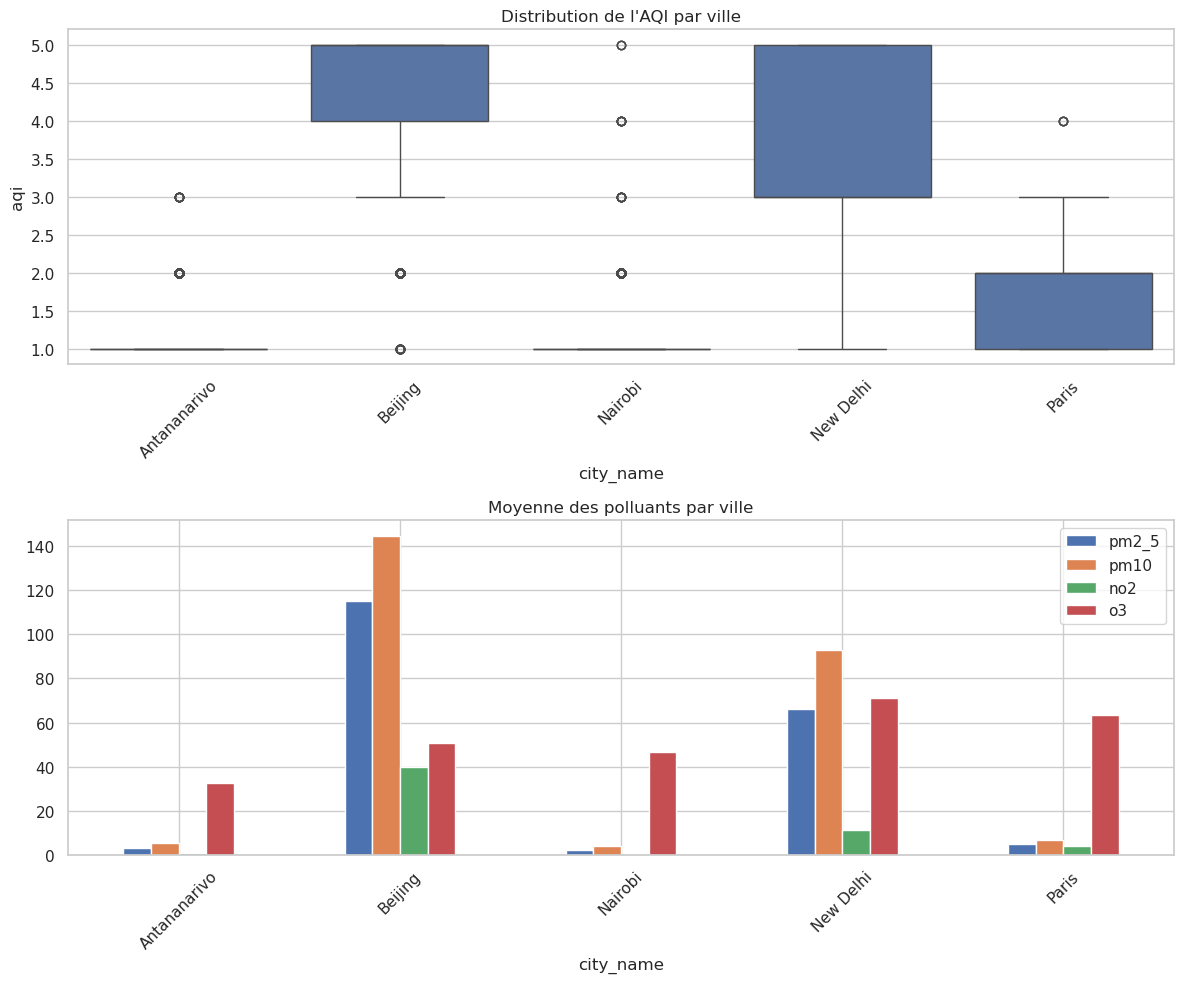

                  mean  median  max
city_name                          
Beijing       4.267929     5.0    5
New Delhi     3.555330     3.0    5
Paris         1.735558     2.0    4
Nairobi       1.188171     1.0    5
Antananarivo  1.136116     1.0    3


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Distribution de l'AQI par ville
sns.boxplot(data=df, x="city_name", y="aqi", ax=axes[0])
axes[0].set_title("Distribution de l'AQI par ville")
axes[0].tick_params(axis="x", rotation=45)

# Moyenne des principaux polluants par ville
city_means = df.groupby("city_name")[["pm2_5", "pm10", "no2", "o3"]].mean()
city_means.plot(kind="bar", ax=axes[1])
axes[1].set_title("Moyenne des polluants par ville")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Classement des villes par AQI moyen
ranking = df.groupby("city_name")["aqi"].agg(["mean", "median", "max"]).sort_values("mean", ascending=False)
print(ranking)

### 5. Évolution temporelle

Nous examinons comment l'AQI évolue dans le temps, son profil moyen sur un cycle de 24 heures, et si les week-ends diffèrent des jours de semaine.

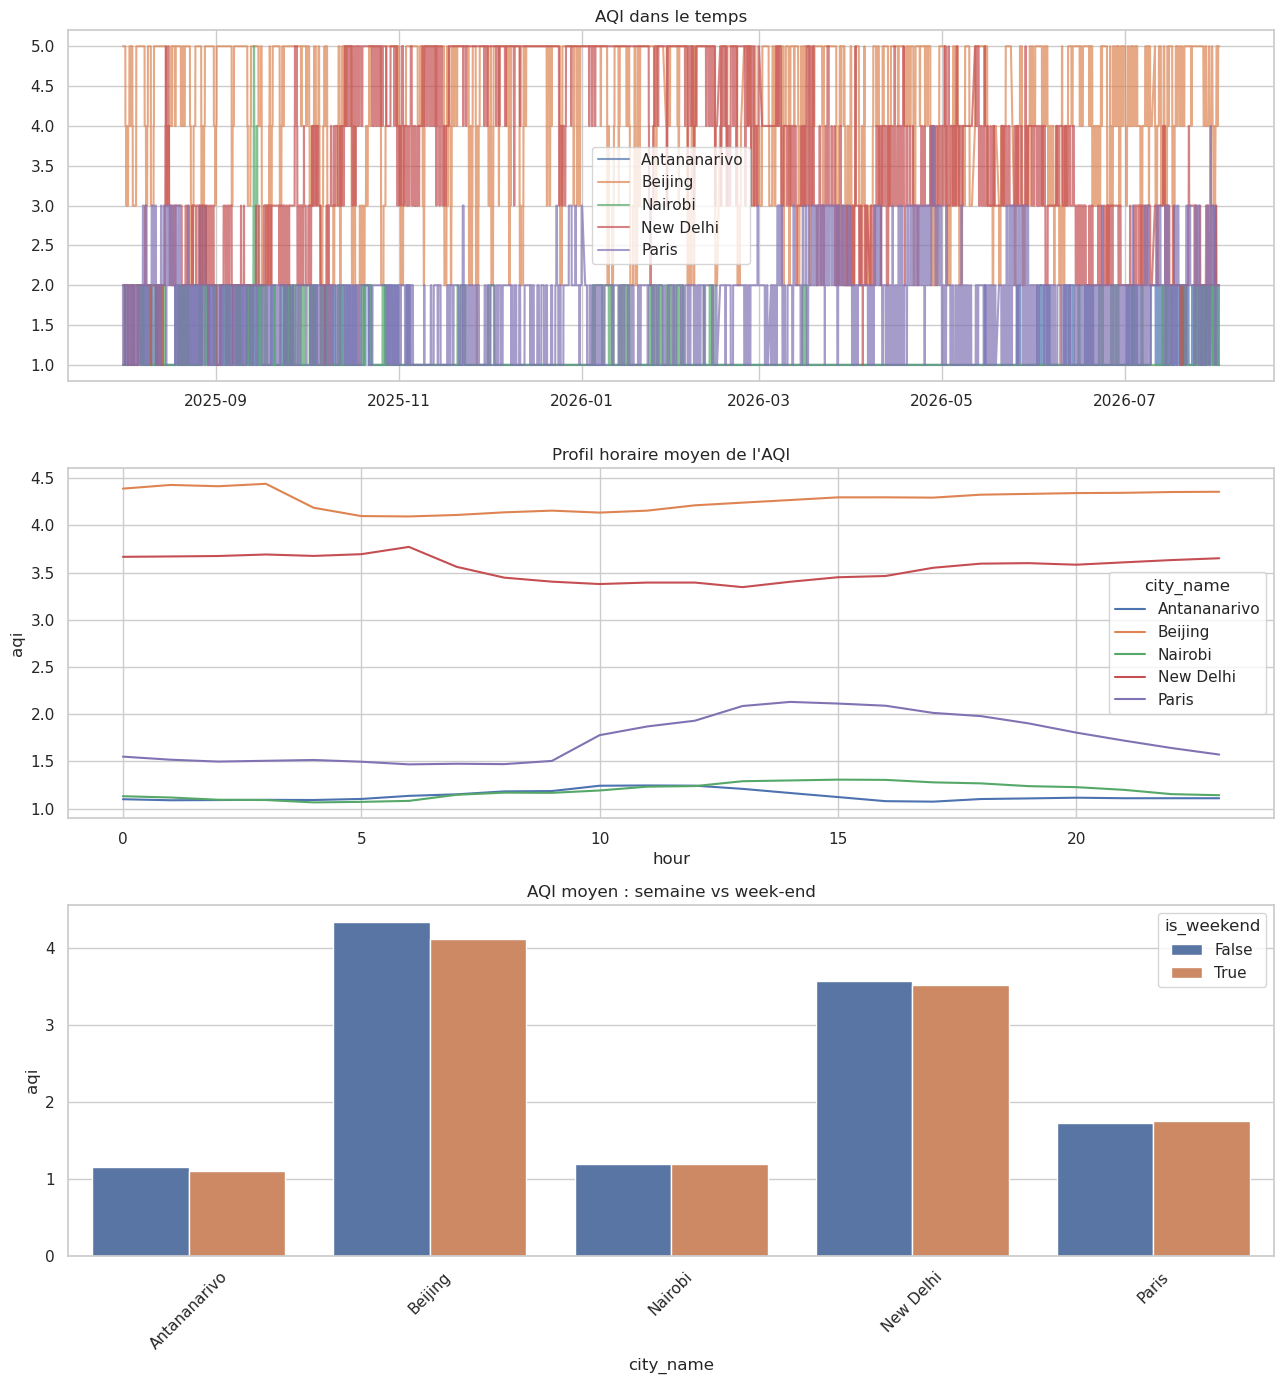

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# Série temporelle de l'AQI par ville
for city in df["city_name"].unique():
    sub = df[df["city_name"] == city].sort_values("timestamp_utc")
    axes[0].plot(sub["timestamp_utc"], sub["aqi"], label=city, alpha=0.7)
axes[0].set_title("AQI dans le temps")
axes[0].legend()

# Profil horaire moyen (cycle jour/nuit — trafic, activité)
hourly = df.groupby(["city_name", "hour"])["aqi"].mean().reset_index()
sns.lineplot(data=hourly, x="hour", y="aqi", hue="city_name", ax=axes[1])
axes[1].set_title("Profil horaire moyen de l'AQI")

# Semaine vs Week-end
weekend_cmp = df.groupby(["city_name", "is_weekend"])["aqi"].mean().reset_index()
sns.barplot(data=weekend_cmp, x="city_name", y="aqi", hue="is_weekend", ax=axes[2])
axes[2].set_title("AQI moyen : semaine vs week-end")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 6. Corrélations entre polluants

Nous mesurons la force avec laquelle chaque polluant évolue avec l'AQI et avec les autres polluants, pour identifier ceux qui influencent réellement l'indice.

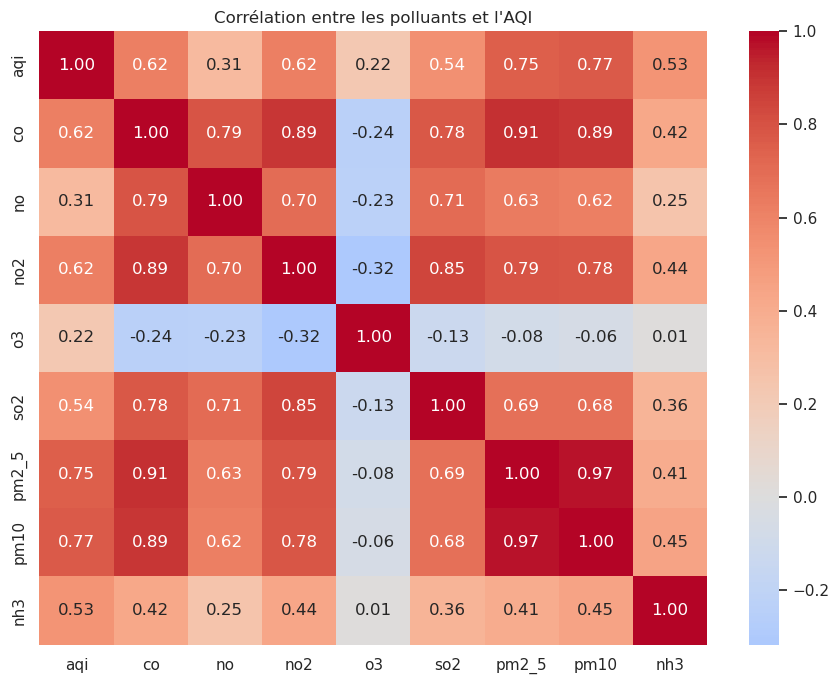

Polluants les plus corrélés à l'AQI (Pearson r, avec test de significativité) :
                r  p_value  significant (p<0.05)
pollutant                                       
pm10       0.7667      0.0                  True
pm2_5      0.7546      0.0                  True
co         0.6204      0.0                  True
no2        0.6165      0.0                  True
so2        0.5399      0.0                  True
nh3        0.5309      0.0                  True
no         0.3115      0.0                  True
o3         0.2250      0.0                  True

Attention : L'AQI d'OpenWeather est lui-même dérivé d'un sous-ensemble de ces concentrations de polluants (PM2.5/PM10 en particulier). Une forte corrélation ici est donc en partie définitoire, pas une découverte purement empirique — considérez-la comme une confirmation des polluants qui pilotent la formule de l'indice, et non comme une nouvelle perspective causale.


In [7]:
plt.figure(figsize=(9, 7))
corr = df[pollutant_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre les polluants et l'AQI")
plt.tight_layout()
plt.show()

# Coefficients de corrélation de Pearson ET p-valeur pour chaque polluant vs AQI.
# Avec un grand N, les p-valeurs sont presque toujours significatives, même pour des corrélations faibles.
# Nous considérons donc la significativité comme un critère minimum et jugeons de la pertinence sur |r|.
sig_rows = []
for col in pollutant_cols:
    if col == "aqi":
        continue
    valid = df[["aqi", col]].dropna()
    r, p = pearsonr(valid["aqi"], valid[col])
    sig_rows.append({"pollutant": col, "r": r, "abs_r": abs(r), "p_value": p, "significant (p<0.05)": p < 0.05})

corr_sig = pd.DataFrame(sig_rows).sort_values("abs_r", ascending=False).set_index("pollutant")
print("Polluants les plus corrélés à l'AQI (Pearson r, avec test de significativité) :")
print(corr_sig[["r", "p_value", "significant (p<0.05)"]].round(4))

print(
    "\nAttention : L'AQI d'OpenWeather est lui-même dérivé d'un sous-ensemble de ces "
    "concentrations de polluants (PM2.5/PM10 en particulier). Une forte corrélation ici est donc "
    "en partie définitoire, pas une découverte purement empirique — considérez-la comme une "
    "confirmation des polluants qui pilotent la formule de l'indice, et non comme une nouvelle "
    "perspective causale."
)

### 7. Distribution géographique

En utilisant les coordonnées latitude/longitude stockées dans dim_city, nous plaçons chaque ville sur une carte et la colorons par AQI moyen pour visualiser rapidement les tendances spatiales.

In [8]:
import plotly.express as px

city_geo = df.groupby(["city_name", "latitude", "longitude"])["aqi"].mean().reset_index()
city_geo.columns = ["city_name", "latitude", "longitude", "avg_aqi"]

fig = px.scatter_geo(
    city_geo,
    lat="latitude",
    lon="longitude",
    color="avg_aqi",
    size="avg_aqi",
    hover_name="city_name",
    color_continuous_scale="RdYlGn_r",
    title="AQI moyen par localisation de la ville",
    projection="natural earth",
)
fig.update_geos(showcountries=True, showcoastlines=True)
fig.show()

print(city_geo.sort_values("avg_aqi", ascending=False))

      city_name  latitude  longitude   avg_aqi
1       Beijing   39.9042   116.4074  4.267929
3     New Delhi   28.6139    77.2090  3.555330
4         Paris   48.8566     2.3522  1.735558
2       Nairobi   -1.2921    36.8219  1.188171
0  Antananarivo  -18.8792    47.5079  1.136116


### 8. Tendances saisonnières / mensuelles

Les données horaires sont bruitées, nous agrégons donc l'AQI par jour et par mois (à partir de la colonne dim_time.date) pour voir la tendance sous-jacente plutôt que les fluctuations ponctuelles.

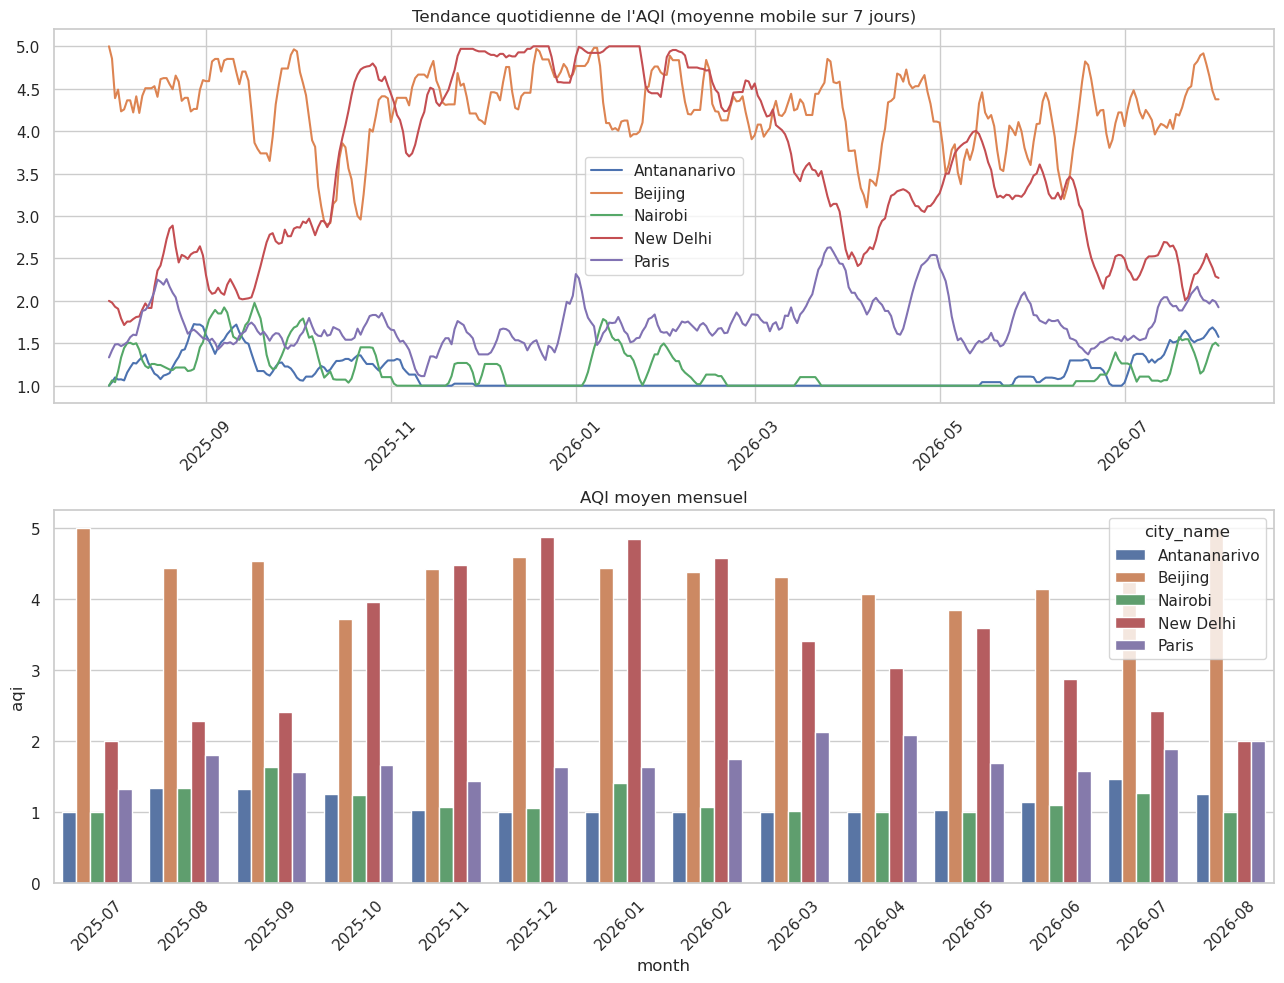

city_name  Antananarivo  Beijing  Nairobi  New Delhi  Paris
month                                                      
2025-07             1.0      5.0      1.0        2.0    1.3
2025-08             1.3      4.4      1.3        2.3    1.8
2025-09             1.3      4.5      1.6        2.4    1.6
2025-10             1.3      3.7      1.2        4.0    1.7
2025-11             1.0      4.4      1.1        4.5    1.4
2025-12             1.0      4.6      1.1        4.9    1.6
2026-01             1.0      4.4      1.4        4.8    1.6
2026-02             1.0      4.4      1.1        4.6    1.7
2026-03             1.0      4.3      1.0        3.4    2.1
2026-04             1.0      4.1      1.0        3.0    2.1
2026-05             1.0      3.8      1.0        3.6    1.7
2026-06             1.1      4.1      1.1        2.9    1.6
2026-07             1.5      4.4      1.3        2.4    1.9
2026-08             1.2      5.0      1.0        2.0    2.0


In [9]:
df["month"] = df["timestamp_utc"].dt.tz_localize(None).dt.to_period("M").astype(str)
df["week"] = df["timestamp_utc"].dt.tz_localize(None).dt.to_period("W").astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Moyenne quotidienne de l'AQI, lissée sur 7 jours (moyenne mobile), par ville
daily = df.groupby(["city_name", "date"])["aqi"].mean().reset_index()
for city in daily["city_name"].unique():
    sub = daily[daily["city_name"] == city].sort_values("date")
    sub["aqi_smooth"] = sub["aqi"].rolling(7, min_periods=1).mean()
    axes[0].plot(sub["date"], sub["aqi_smooth"], label=city)
axes[0].set_title("Tendance quotidienne de l'AQI (moyenne mobile sur 7 jours)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# AQI mensuel moyen par ville
monthly = df.groupby(["city_name", "month"])["aqi"].mean().reset_index()
sns.barplot(data=monthly, x="month", y="aqi", hue="city_name", ax=axes[1])
axes[1].set_title("AQI moyen mensuel")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(monthly.pivot(index="month", columns="city_name", values="aqi").round(1))

### 9. Détection d'anomalies

Nous signalons les lectures qui s'écartent fortement du comportement récent d'une ville (z-score sur une fenêtre glissante), ce qui peut indiquer des problèmes de capteur ou de réels pics de pollution à étudier.

**Pourquoi une approche multivariée, et pas seulement le PM2.5 :** un événement de pollution réel fait généralement bouger plusieurs polluants simultanément (voir la matrice de corrélation ci-dessus). Se concentrer uniquement sur le PM2.5 ferait manquer des pics qui se manifestent surtout par le NO2, l'O3 ou le CO, et pourrait aussi signaler du bruit sur un seul capteur comme une anomalie "réelle". Nous calculons un z-score glissant pour chacun des polluants PM2.5, PM10, NO2, O3 et CO, et signalons une lecture lorsqu'**au moins l'un d'eux** dépasse le seuil. Le score z maximum (`z_max`) est utilisé pour le classement et les graphiques, tandis que `n_pollutants_flagged` montre combien de polluants ont bougé ensemble (un signal plus fort d'un événement réel versus un seul capteur bruyant).

**Pourquoi un seuil de 3 et une fenêtre de 24h :** pour une distribution approximativement normale, |z| > 3 couvre environ 99,7% de la variation "normale", donc moins de 0,3% des points devraient être signalés par hasard pour un polluant donné. Tester 5 polluants indépendamment augmente ce risque de faux positifs à environ 1 − (0,997)^5 ≈ 1,5% ; d'où l'importance de `n_pollutants_flagged`. Une lecture signalée sur plusieurs polluants à la fois est bien moins probable comme faux positif qu'une lecture signalée sur un seul polluant. La fenêtre de 24 heures équilibre la stabilité (assez de points pour estimer une moyenne/écart-type significative) et la réactivité (suffisamment courte pour capturer les pics relatifs au cycle journalier, pas seulement les dérives hebdomadaires). Le seuil et la fenêtre peuvent être ajustés selon les besoins ; le tableau de bord interactif les expose comme des curseurs pour cette raison.

Anomalies détectées (multivariées) : 1149
       city_name             timestamp_utc  pm2_5   pm10    no2      o3  \
8512     Beijing 2025-08-04 03:00:00+00:00  53.21  56.45  28.99   22.15   
8513     Beijing 2025-08-04 04:00:00+00:00  43.59  46.42  25.42   28.15   
8539     Beijing 2025-08-05 06:00:00+00:00  46.71  49.46  10.85   95.71   
8540     Beijing 2025-08-05 07:00:00+00:00  67.12  70.57   9.92  126.35   
25433  New Delhi 2025-08-05 08:00:00+00:00   5.22  11.42   2.11   59.58   
...          ...                       ...    ...    ...    ...     ...   
16895    Beijing 2026-07-28 06:23:00+00:00  63.44  65.10   2.23  139.26   
25282    Nairobi 2026-07-28 09:33:48+00:00   6.02   8.62   0.18   66.52   
42163      Paris 2026-07-29 14:00:33+00:00  11.67  13.12   0.51  134.39   
42164      Paris 2026-07-29 16:17:49+00:00  14.80  16.35   0.77  140.64   
33683  New Delhi 2026-07-29 18:03:25+00:00  28.06  42.74  27.93    9.70   

           co  aqi     z_max  n_pollutants_flagged  
8512

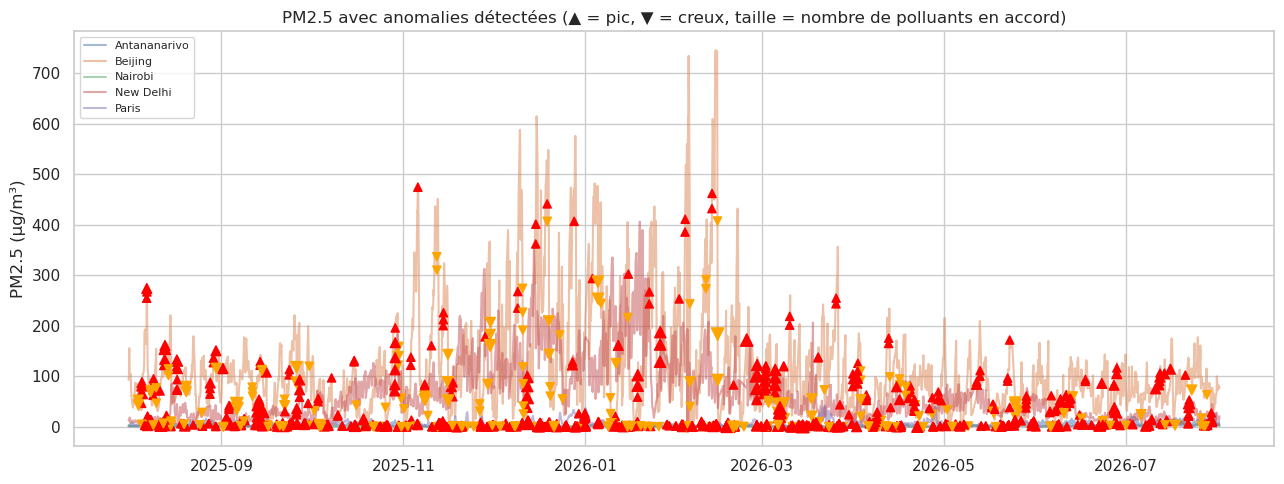


Anomalies par ville :
              anomalies  total_points   pct
city_name                                  
Paris               329          8482  3.88
Nairobi             319          8386  3.80
Beijing             260          8506  3.06
Antananarivo        138          8434  1.64
New Delhi           103          8386  1.23


In [10]:
ANOMALY_COLUMNS = ["pm2_5", "pm10", "no2", "o3", "co"]

def flag_anomalies_multivariate(g, columns=ANOMALY_COLUMNS, window=24, threshold=3):
    g = g.sort_values("timestamp_utc").copy()
    z_cols = []
    for col in columns:
        rolling_mean = g[col].rolling(window, min_periods=5).mean()
        rolling_std = g[col].rolling(window, min_periods=5).std()
        z = (g[col] - rolling_mean) / rolling_std
        z = z.replace([np.inf, -np.inf], np.nan)  # Évite la division par zéro
        g[f"z_{col}"] = z
        z_cols.append(f"z_{col}")

    g["z_max"] = g[z_cols].abs().max(axis=1)              # Polluant le plus aberrant
    g["n_pollutants_flagged"] = (g[z_cols].abs() > threshold).sum(axis=1)  # Accord entre polluants
    g["is_anomaly"] = g["z_max"] > threshold
    return g

# Détection des anomalies, par ville, sur PM2.5 / PM10 / NO2 / O3 / CO simultanément
df_anomalies = df.groupby("city_name", group_keys=False)[df.columns].apply(
    lambda g: flag_anomalies_multivariate(g, window=24, threshold=3)
)

anomalies = df_anomalies[df_anomalies["is_anomaly"]].sort_values("timestamp_utc")
print(f"Anomalies détectées (multivariées) : {len(anomalies)}")
print(
    anomalies[["city_name", "timestamp_utc", "pm2_5", "pm10", "no2", "o3", "co",
               "aqi", "z_max", "n_pollutants_flagged"]]
)
print(
    f"\nParmi celles-ci, signalées sur 2+ polluants à la fois (signal plus fort, moins susceptible d'être un bruit de capteur isolé) : "
    f"{(anomalies['n_pollutants_flagged'] >= 2).sum()}"
)

# Visualisation : PM2.5 avec anomalies, en distinguant les pics (rouge) et les creux (orange).
# La taille du marqueur reflète le nombre de polluants en accord sur l'anomalie.
fig, ax = plt.subplots(figsize=(13, 5))
for city in df["city_name"].unique():
    sub = df_anomalies[df_anomalies["city_name"] == city].sort_values("timestamp_utc")
    ax.plot(sub["timestamp_utc"], sub["pm2_5"], label=city, alpha=0.5)

    anom_high = sub[(sub["is_anomaly"]) & (sub["z_pm2_5"] > 0)]
    anom_low = sub[(sub["is_anomaly"]) & (sub["z_pm2_5"] <= 0)]

    if len(anom_high):
        ax.scatter(anom_high["timestamp_utc"], anom_high["pm2_5"],
                   color="red", zorder=5, marker="^",
                   s=20 + 15 * anom_high["n_pollutants_flagged"])
    if len(anom_low):
        ax.scatter(anom_low["timestamp_utc"], anom_low["pm2_5"],
                   color="orange", zorder=5, marker="v",
                   s=20 + 15 * anom_low["n_pollutants_flagged"])

ax.set_title("PM2.5 avec anomalies détectées (▲ = pic, ▼ = creux, taille = nombre de polluants en accord)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Résumé : nombre d'anomalies ET pourcentage par ville
print("\nAnomalies par ville :")
counts = anomalies["city_name"].value_counts()
totals = df_anomalies["city_name"].value_counts()
summary = pd.DataFrame({"anomalies": counts, "total_points": totals})
summary["pct"] = (summary["anomalies"] / summary["total_points"] * 100).round(2)
summary = summary.sort_values("pct", ascending=False)
print(summary)

### 10. Conclusion / résumé

Un tableau de bord d'une page, en langage clair : voyants de statut, chiffres clés et verdict rédigé — conçu pour que tout le monde (pas seulement un analyste de données) comprenne en un coup d'œil l'état de santé de l'entrepôt et les principaux enseignements.

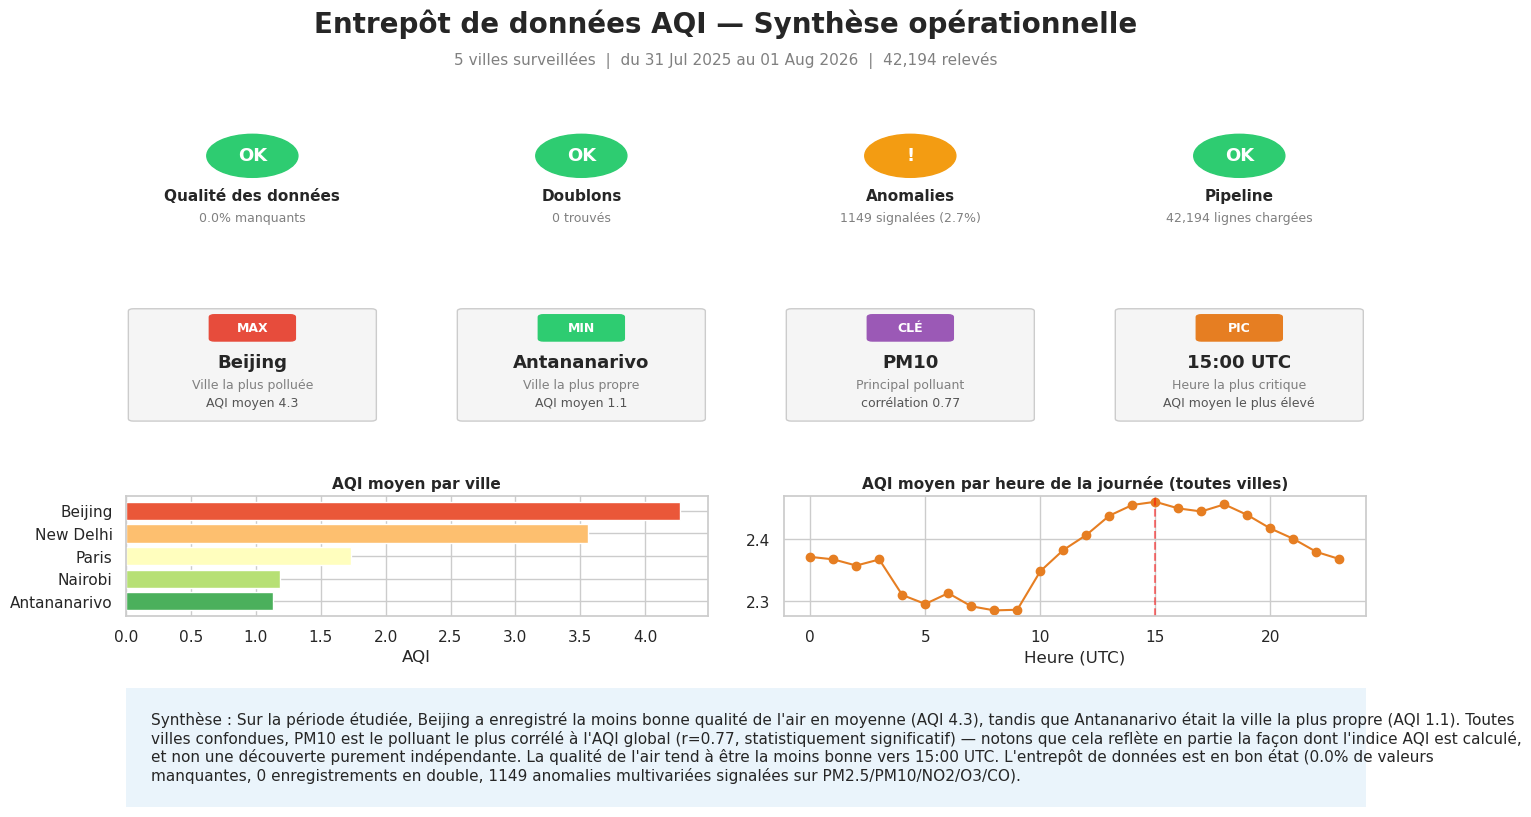

In [11]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# --- Calcul de tous les indicateurs de synthèse ---
n_cities = df["city_name"].nunique()
n_rows = len(df)
n_missing = df[pollutant_cols].isna().sum().sum()
missing_pct = n_missing / (n_rows * len(pollutant_cols)) * 100
n_dupes = df.duplicated(subset=["city_name", "timestamp_utc"]).sum()
n_anomalies = len(anomalies)
anomaly_pct = n_anomalies / n_rows * 100

most_polluted = ranking["mean"].idxmax()
most_polluted_val = ranking["mean"].max()
least_polluted = ranking["mean"].idxmin()
least_polluted_val = ranking["mean"].min()

top_pollutant = corr_sig["abs_r"].idxmax()
top_pollutant_corr = corr_sig.loc[top_pollutant, "r"]

peak_hour = hourly.groupby("hour")["aqi"].mean().idxmax()
period_start = df["timestamp_utc"].min().strftime("%d %b %Y")
period_end = df["timestamp_utc"].max().strftime("%d %b %Y")

# --- Fonction d'état pour les voyants ---
def status_color(pct, good=1, warn=5):
    if pct < good:
        return "#2ecc71", "OK"
    elif pct < warn:
        return "#f39c12", "SURVEILLANCE"
    else:
        return "#e74c3c", "PROBLÈME"

quality_color, quality_label = status_color(missing_pct, good=1, warn=5)
anomaly_color, anomaly_label = status_color(anomaly_pct, good=1, warn=3)
dupe_color, dupe_label = status_color(n_dupes / n_rows * 100, good=0.1, warn=1)

# --- Mise en page du tableau de bord ---
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.6, wspace=0.3)

# Titre
fig.text(0.5, 0.97, "Entrepôt de données AQI — Synthèse opérationnelle", ha="center", fontsize=20, fontweight="bold")
fig.text(0.5, 0.935, f"{n_cities} villes surveillées  |  du {period_start} au {period_end}  |  {n_rows:,} relevés",
         ha="center", fontsize=11, color="gray")

# --- Ligne 1 : Voyants d'état (indicateurs de trafic) ---
status_items = [
    ("Qualité des données", quality_label, quality_color, f"{missing_pct:.1f}% manquants"),
    ("Doublons", dupe_label, dupe_color, f"{n_dupes} trouvés"),
    ("Anomalies", anomaly_label, anomaly_color, f"{n_anomalies} signalées ({anomaly_pct:.1f}%)"),
    ("Pipeline", "OK" if n_rows > 0 else "PROBLÈME", "#2ecc71" if n_rows > 0 else "#e74c3c", f"{n_rows:,} lignes chargées"),
]
for i, (title, label, color, detail) in enumerate(status_items):
    ax = fig.add_subplot(gs[0, i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    circle = plt.Circle((0.5, 0.65), 0.18, color=color)
    ax.add_patch(circle)
    symbol = "OK" if label == "OK" else ("!" if label == "SURVEILLANCE" else "X")
    ax.text(0.5, 0.65, symbol, ha="center", va="center", fontsize=13, color="white", fontweight="bold")
    ax.text(0.5, 0.28, title, ha="center", fontsize=11, fontweight="bold")
    ax.text(0.5, 0.10, detail, ha="center", fontsize=9, color="gray")

# --- Ligne 2 : Cartes des principaux résultats ---
findings = [
    ("MAX", "Ville la plus polluée", most_polluted, f"AQI moyen {most_polluted_val:.1f}", "#e74c3c"),
    ("MIN", "Ville la plus propre", least_polluted, f"AQI moyen {least_polluted_val:.1f}", "#2ecc71"),
    ("CLÉ", "Principal polluant", top_pollutant.upper(), f"corrélation {top_pollutant_corr:.2f}", "#9b59b6"),
    ("PIC", "Heure la plus critique", f"{peak_hour}:00 UTC", "AQI moyen le plus élevé", "#e67e22"),
]
for i, (tag, title, value, detail, color) in enumerate(findings):
    ax = fig.add_subplot(gs[1, i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle="round,pad=0.02",
                                 facecolor="#f5f5f5", edgecolor="#ccc", linewidth=1))
    ax.add_patch(FancyBboxPatch((0.35, 0.72), 0.3, 0.18, boxstyle="round,pad=0.02",
                                 facecolor=color, edgecolor=color))
    ax.text(0.5, 0.81, tag, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(0.5, 0.48, value, ha="center", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.30, title, ha="center", fontsize=9, color="gray")
    ax.text(0.5, 0.15, detail, ha="center", fontsize=9, color="#555")

# --- Ligne 3 : Mini histogramme (classement des villes) ---
ax_bar = fig.add_subplot(gs[2, 0:2])
ranking_sorted = ranking["mean"].sort_values()
colors_bar = sns.color_palette("RdYlGn_r", len(ranking_sorted))
ax_bar.barh(ranking_sorted.index, ranking_sorted.values, color=colors_bar)
ax_bar.set_title("AQI moyen par ville", fontsize=11, fontweight="bold")
ax_bar.set_xlabel("AQI")

# --- Ligne 3 : Mini profil horaire ---
ax_line = fig.add_subplot(gs[2, 2:4])
overall_hourly = df.groupby("hour")["aqi"].mean()
ax_line.plot(overall_hourly.index, overall_hourly.values, marker="o", color="#e67e22")
ax_line.axvline(peak_hour, color="red", linestyle="--", alpha=0.5)
ax_line.set_title("AQI moyen par heure de la journée (toutes villes)", fontsize=11, fontweight="bold")
ax_line.set_xlabel("Heure (UTC)")

# --- Ligne 4 : Verdict rédigé en langage clair ---
ax_text = fig.add_subplot(gs[3, :])
ax_text.axis("off")

verdict = (
    f"Synthèse : Sur la période étudiée, {most_polluted} a enregistré la moins bonne qualité de l'air en moyenne "
    f"(AQI {most_polluted_val:.1f}), tandis que {least_polluted} était la ville la plus propre (AQI {least_polluted_val:.1f}). "
    f"Toutes villes confondues, {top_pollutant.upper()} est le polluant le plus corrélé à l'AQI global "
    f"(r={top_pollutant_corr:.2f}, statistiquement significatif) — notons que cela reflète en partie la façon dont l'indice "
    f"AQI est calculé, et non une découverte purement indépendante. "
    f"La qualité de l'air tend à être la moins bonne vers {peak_hour}:00 UTC. "
    f"L'entrepôt de données est en {'bon état' if quality_label == 'OK' and dupe_label == 'OK' else 'un état nécessitant une révision'} "
    f"({missing_pct:.1f}% de valeurs manquantes, {n_dupes} enregistrements en double, {n_anomalies} anomalies multivariées signalées "
    f"sur PM2.5/PM10/NO2/O3/CO)."
)
ax_text.add_patch(FancyBboxPatch((0.0, 0.0), 1.0, 1.0, boxstyle="round,pad=0.02",
                                  facecolor="#eaf4fb", edgecolor="#3498db", linewidth=1.5, transform=ax_text.transAxes))
ax_text.text(0.02, 0.5, verdict, ha="left", va="center", fontsize=11, wrap=True,
             transform=ax_text.transAxes, family="sans-serif")

plt.show()